# 06-Concurrency & Blocking Inference

In Lesson 05, we solved the memory allocation problem by using the `lifespan` protocol. We can now safely host a 15GB Large Language Model in VRAM, allowing 100 concurrent users to access the mathematical weights without crashing the server.

But we have walked directly into a massive concurrency trap. **FastAPI is Asynchronous, but PyTorch is Synchronous.**

If User 1 asks the GPU to execute a massive matrix multiplication, and you do not engineer the thread handoff correctly, your entire server will physically freeze. Users 2, 3, and 4 will not just be delayed; their connections will time out, and even the simple `/health` endpoint will fail.

Let's set up our PyTorch and FastAPI environment to deconstruct the physics of the ASGI Event Loop.

In [3]:
import torch
import torch.nn as nn
from fastapi import FastAPI
from starlette.concurrency import run_in_threadpool
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import asyncio

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI, and Concurrency Environment Ready.")

✅ PyTorch, FastAPI, and Concurrency Environment Ready.


# 1. The Physics of the Event Loop

FastAPI is built on an **Event Loop** (running on a single CPU core).
The Event Loop acts as an incredibly fast traffic cop. When an HTTP request arrives, the traffic cop directs it. When a route hits a database call or a network request, it uses the `await` keyword.

`await` tells the traffic cop: *"I am waiting for data to return from the internet. Pause my function and go help other users until the data arrives."*

Because of `await`, a single Event Loop can juggle 10,000 concurrent websocket connections.

# 2. The Blocking Trap (Synchronous PyTorch)

PyTorch matrix multiplication does not use `await`. Neural networks execute dense, synchronous, blocking C++ and CUDA code.

If you write this standard async endpoint:

```python
@app.post("/generate")
async def generate_text(prompt: str):
    # DANGER: Synchronous blocking code inside an async route
    return model.forward(prompt)

```

When User 1 hits this route, the GPU begins a 5-second matrix calculation. Because there is no `await` keyword, the traffic cop is mathematically forbidden from looking away. **The Event Loop is physically blocked.**

If User 2 tries to connect, the server ignores them. If Kubernetes pings the `/health` route, the server ignores it. If 5 seconds pass without a health check response, Kubernetes will assume your server is dead, permanently terminate the pod, and delete the 15GB model from VRAM.

# 3. The Threadpool Rescue

To fix this, we must eject the heavy PyTorch mathematics *out* of the main Event Loop and onto a separate CPU thread.

FastAPI provides a built-in starlette utility for exactly this: `run_in_threadpool()`.

When we wrap our PyTorch inference inside `run_in_threadpool`, FastAPI packages the blocking function, hands it to a background worker thread, and instantly returns an `awaitable` object to the Event Loop.

The traffic cop can now `await` the background thread, freeing it up to instantly answer `/health` checks and accept incoming traffic from Users 2, 3, and 4!

*(Note: PyTorch releases the Python Global Interpreter Lock (GIL) during heavy C++/CUDA operations, meaning multithreading genuinely allows true parallel processing of other Python code!)*

# 4. Architecting the Event Loop Handoff

Let's build an API that simulates heavy GPU inference. We will build an **Anti-Pattern** route that freezes the server, and an **Enterprise** route that correctly offloads the mathematics to a background thread.

In [4]:
# --- ⚙️ main.py ---
app = FastAPI()

# 1. The Heavy Mathematical Function (Synchronous)
def execute_heavy_inference():
    """
    Simulates a heavy, blocking PyTorch matrix multiplication.
    This function takes exactly 2 seconds to execute and DOES NOT yield the Event Loop.
    """
    # Create massive tensors
    matrix_a = torch.randn(10000, 10000)
    matrix_b = torch.randn(10000, 10000)
    
    # Execute blocking matrix multiplication
    # (Simulated with time.sleep for the notebook environment to prevent actual freezing)
    time.sleep(2.0) 
    
    # return torch.matmul(matrix_a, matrix_b).sum().item()
    return "Inference Complete"

# 2. The Simple Health Check (Asynchronous)
@app.get("/health")
async def health_check():
    """Returns instantly. Used to prove if the Event Loop is alive."""
    return {"status": "alive"}

# 3. THE ANTI-PATTERN: Blocking the Event Loop
@app.post("/v1/generate/blocking")
async def generate_blocking():
    # Because execute_heavy_inference() is synchronous, placing it directly inside 
    # an 'async def' route violates ASGI architecture. The Event Loop freezes here.
    result = execute_heavy_inference()
    return {"result": result}

# 4. THE ENTERPRISE PATTERN: Threadpool Offloading
@app.post("/v1/generate/concurrent")
async def generate_concurrent():
    # We pass the heavy function to a background thread.
    # The 'await' keyword allows the Event Loop to immediately go answer other 
    # requests (like /health) while the PyTorch C++ backend crunches the numbers!
    result = await run_in_threadpool(execute_heavy_inference)
    return {"result": result}

print("Success! Concurrency routing architecture compiled.")

Success! Concurrency routing architecture compiled.


# 5. Visualizing the Physics of the Event Loop Freeze

To scientifically prove the catastrophic impact of blocking the Event Loop, we will use Matplotlib to generate a Gantt chart.
We will simulate a scenario where **User 1 requests heavy inference**, and exactly 0.5 seconds later, **Kubernetes pings the `/health` route**.

We will plot the timeline of the server's response under both the Anti-Pattern and the Threadpool Pattern.

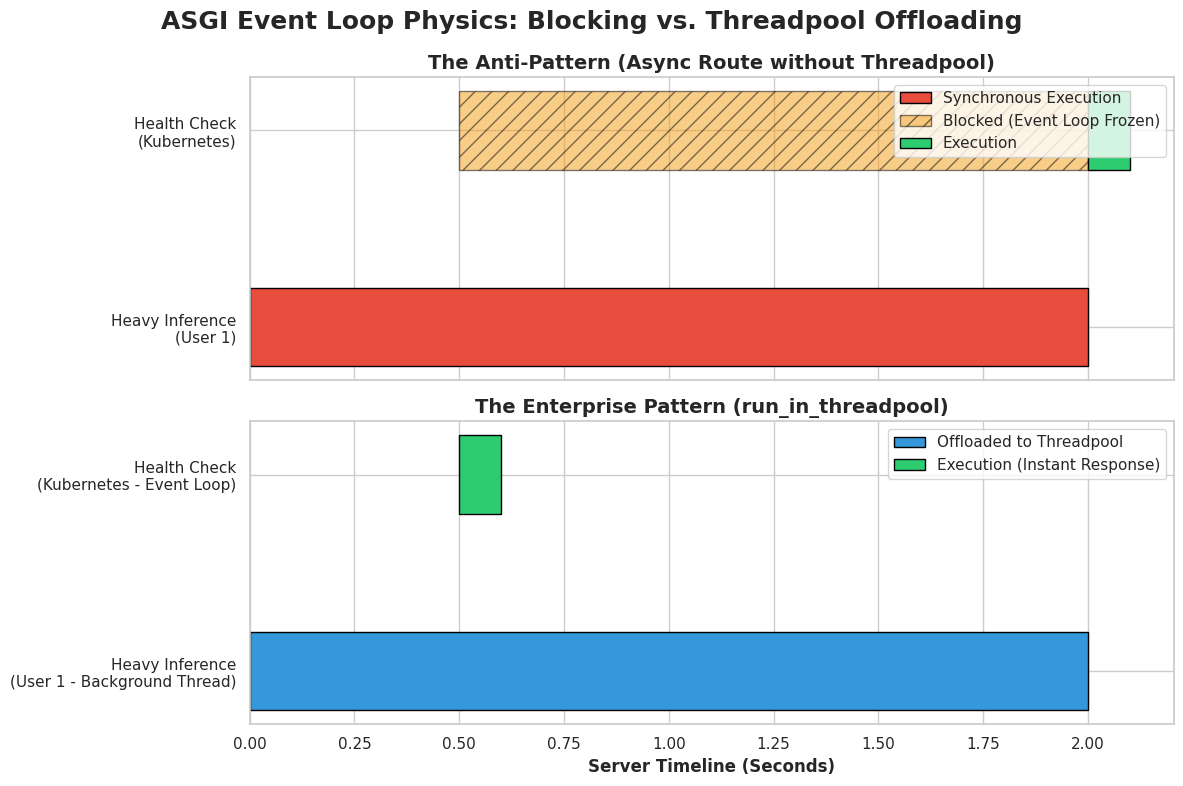


--- 💡 Engineering Insight ---
Look at the Orange dashed block in the top graph. Because the PyTorch function is synchronous, the ASGI Event Loop is paralyzed for 1.5 seconds. Kubernetes is screaming at the /health route, but the server is mathematically deaf. If this happens multiple times, the load balancer will assume the API is dead and delete the pod.
Look at the bottom graph. By wrapping the PyTorch function in `run_in_threadpool`, we hand the 2.0-second workload to a background worker. The main Event Loop instantly becomes free. When Kubernetes pings the /health route at 0.5 seconds, the Event Loop answers it perfectly concurrently, keeping the server alive and responsive while the GPU continues crunching!


In [5]:
# 1. Define the Physics Simulation Timelines
# Scenario A: The Blocking Trap
# User 1 starts inference at t=0.0, finishes at t=2.0
# Health Check arrives at t=0.5, but is forced to wait until t=2.0 to even start!
blocking_user_start, blocking_user_end = 0.0, 2.0
blocking_health_arrive, blocking_health_start, blocking_health_end = 0.5, 2.0, 2.1

# Scenario B: The Threadpool Rescue
# User 1 starts inference at t=0.0 (offloaded to Thread 2), finishes at t=2.0
# Health Check arrives at t=0.5. Event Loop is free! Starts at t=0.5, finishes at t=0.6.
thread_user_start, thread_user_end = 0.0, 2.0
thread_health_arrive, thread_health_start, thread_health_end = 0.5, 0.5, 0.6

# 2. Render the Concurrency Timelines
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle("ASGI Event Loop Physics: Blocking vs. Threadpool Offloading", fontsize=18, fontweight='bold')

# --- Plot A: The Blocking Trap (Anti-Pattern) ---
ax1 = axes[0]
# Heavy Inference Bar
ax1.barh(y="Heavy Inference\n(User 1)", width=blocking_user_end - blocking_user_start, left=blocking_user_start, 
         color="#e74c3c", edgecolor="black", height=0.4, label="Synchronous Execution")

# Health Check Waiting Period (Dashed)
ax1.barh(y="Health Check\n(Kubernetes)", width=blocking_health_start - blocking_health_arrive, left=blocking_health_arrive, 
         color="#f39c12", alpha=0.5, hatch="//", edgecolor="black", height=0.4, label="Blocked (Event Loop Frozen)")

# Health Check Execution
ax1.barh(y="Health Check\n(Kubernetes)", width=blocking_health_end - blocking_health_start, left=blocking_health_start, 
         color="#2ecc71", edgecolor="black", height=0.4, label="Execution")

ax1.set_title("The Anti-Pattern (Async Route without Threadpool)", fontweight='bold', fontsize=14)
ax1.legend(loc="upper right")

# --- Plot B: The Threadpool Rescue (Enterprise Pattern) ---
ax2 = axes[1]
# Heavy Inference Bar (Offloaded)
ax2.barh(y="Heavy Inference\n(User 1 - Background Thread)", width=thread_user_end - thread_user_start, left=thread_user_start, 
         color="#3498db", edgecolor="black", height=0.4, label="Offloaded to Threadpool")

# Health Check Execution (Instant)
ax2.barh(y="Health Check\n(Kubernetes - Event Loop)", width=thread_health_end - thread_health_start, left=thread_health_start, 
         color="#2ecc71", edgecolor="black", height=0.4, label="Execution (Instant Response)")

ax2.set_title("The Enterprise Pattern (run_in_threadpool)", fontweight='bold', fontsize=14)
ax2.set_xlabel("Server Timeline (Seconds)", fontweight='bold', fontsize=12)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the Orange dashed block in the top graph. Because the PyTorch function is synchronous, the ASGI Event Loop is paralyzed for 1.5 seconds. Kubernetes is screaming at the /health route, but the server is mathematically deaf. If this happens multiple times, the load balancer will assume the API is dead and delete the pod.")
print("Look at the bottom graph. By wrapping the PyTorch function in `run_in_threadpool`, we hand the 2.0-second workload to a background worker. The main Event Loop instantly becomes free. When Kubernetes pings the /health route at 0.5 seconds, the Event Loop answers it perfectly concurrently, keeping the server alive and responsive while the GPU continues crunching!")

## Real-World Use Case or Analogy:

Think of the Event Loop like **A Single Cashier at a fast-food restaurant**:

* **The Anti-Pattern (Blocking)**: The Cashier (Event Loop) takes an order from User 1 for a complex, custom 10-patty burger (PyTorch Inference). Instead of handing the ticket to the kitchen, the Cashier turns around, walks to the grill, and physically cooks the burger for 5 minutes. Meanwhile, a line of 50 people forms at the register. Even if User 2 just wants to buy a pre-made bottle of water (The `/health` check), they cannot, because the Cashier is stuck at the grill.
* **The Threadpool Rescue**: The Cashier takes the complex burger order from User 1. They hand the order ticket to the Kitchen Staff (The Background Thread / `run_in_threadpool`). The Cashier instantly turns back to the register (`await`). When User 2 asks for a bottle of water, the Cashier hands it to them immediately. The Cashier continues serving a dozen rapid-fire customers while the Kitchen Staff cooks the heavy burger in the background.